# Firstly, we would want to generate some graph using the SBM-family models and make some basic observations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from graspologic.simulations import sbm
from graspologic.plot import heatmap

sns.set_context('talk')
np.random.seed(42)

# --- Generate Basic SBM: 3 communities, 50 nodes each ---

n = [50, 50, 50]  # nodes per community

# Block probability matrix
# High prob on diagonal (within community), low prob off diagonal (between communities)
B = np.array([
    [0.7, 0.05, 0.05],
    [0.05, 0.7, 0.05],
    [0.05, 0.05, 0.7],
])

A, labels = sbm(n, B, return_labels=True)

print(f'Adjacency matrix shape: {A.shape}')
print(f'Communities: {np.unique(labels, return_counts=True)}')

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Adjacency matrix shape: (150, 150)
Communities: (array([0, 1, 2], dtype=int64), array([50, 50, 50], dtype=int64))


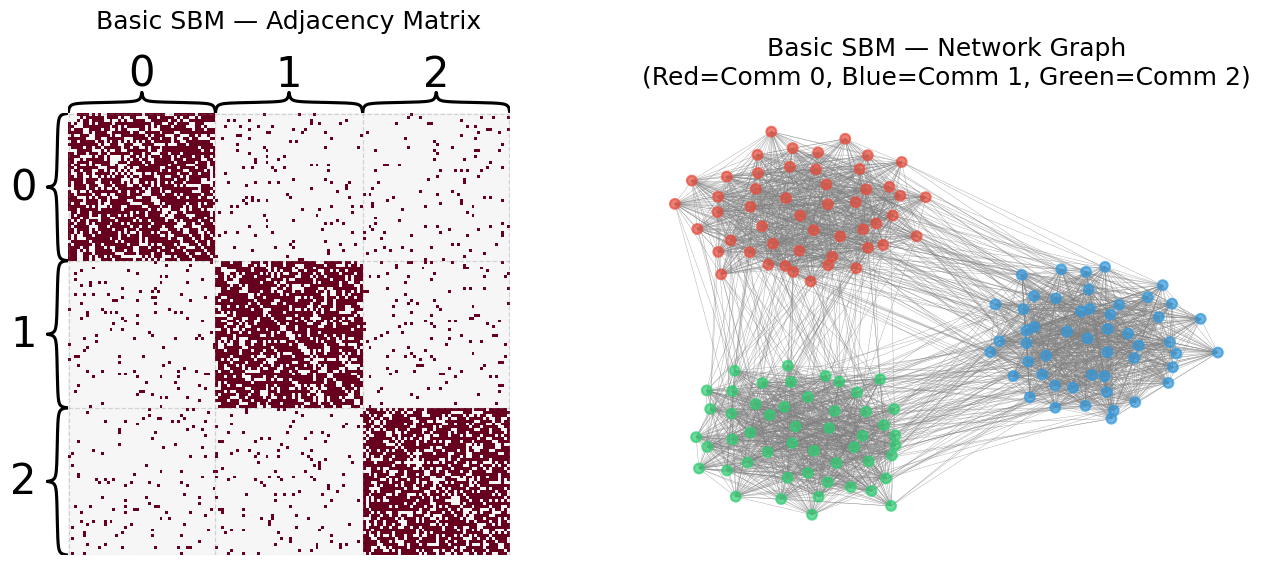

In [ ]:
# Now we would like to visualize the graph representation using heatmap
# and visualizing the graph 
# Visualize as heatmap — should see 3 clear dark blocks on the diagonal
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
heatmap(
    A,
    inner_hier_labels=labels,
    title='Basic SBM — Adjacency Matrix',
    ax=axs[0],
    cbar=False
)

# Network graph
G = nx.from_numpy_array(A)
color_map = ['#e74c3c', '#3498db', '#2ecc71']  # red, blue, green
node_colors = [color_map[labels[node]] for node in G.nodes()]
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G, pos=pos,
    node_color=node_colors,
    node_size=50,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.3,
    ax=axs[1]
)
axs[1].set_title('Basic SBM — Network Graph\n(Red=Comm 0, Blue=Comm 1, Green=Comm 2)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Now we want to generate a DSBM sample graph, same specific as the 
# above generated SBM data - just different model
from graspologic.simulations import sbm

# --- Generate DCSBM: 3 communities, 50 nodes each ---

n_nodes = 150
n_per_block = 50

# Sample theta for each node from uniform distribution [0, 1]
theta = np.random.uniform(0, 1, size=n_nodes)

# Block probability matrix (same structure as basic SBM)
B_dc = np.array([
    [0.7, 0.05, 0.05],
    [0.05, 0.7, 0.05],
    [0.05, 0.05, 0.7],
])

# Build the full probability matrix P manually
# P_ij = theta_i * theta_j * B[community_i][community_j]
labels_dc = np.repeat([0, 1, 2], n_per_block)

P_dc = np.zeros((n_nodes, n_nodes))
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            P_dc[i, j] = theta[i] * theta[j] * B_dc[labels_dc[i], labels_dc[j]]

# Sample adjacency matrix from P
A_dc = (np.random.rand(n_nodes, n_nodes) < P_dc).astype(int)
A_dc = np.triu(A_dc, 1)   # keep upper triangle only (undirected)
A_dc = A_dc + A_dc.T      # symmetrize

print(f'Adjacency matrix shape: {A_dc.shape}')
print(f'Theta min: {theta.min():.3f}, max: {theta.max():.3f}, mean: {theta.mean():.3f}')

Adjacency matrix shape: (150, 150)
Theta min: 0.008, max: 0.999, mean: 0.473


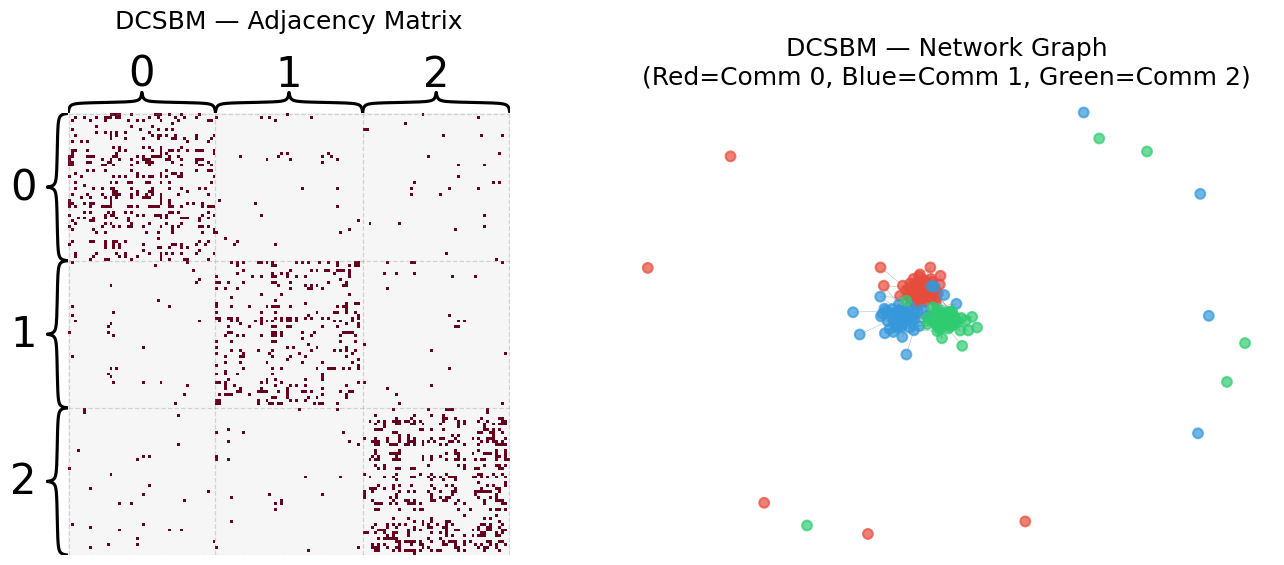

In [5]:
# Visualize DCSBM as heatmap + network graph
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
heatmap(
    A_dc,
    inner_hier_labels=labels_dc,
    title='DCSBM — Adjacency Matrix',
    ax=axs[0],
    cbar=False
)

# Network graph
G_dc = nx.from_numpy_array(A_dc)
color_map = ['#e74c3c', '#3498db', '#2ecc71']
node_colors_dc = [color_map[labels_dc[node]] for node in G_dc.nodes()]
pos_dc = nx.spring_layout(G_dc, seed=42)

nx.draw_networkx(
    G_dc, pos=pos_dc,
    node_color=node_colors_dc,
    node_size=50,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.3,
    ax=axs[1]
)
axs[1].set_title('DCSBM — Network Graph\n(Red=Comm 0, Blue=Comm 1, Green=Comm 2)')
axs[1].axis('off')

plt.tight_layout()
plt.show()